## Setup

In [83]:
pip install pandas matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [84]:
import pandas as pd

## Load and First Look at the Data

In [85]:
df_2024 = pd.read_csv('data/approvals_issued_2024_datasd.csv')
df_2025 = pd.read_csv('data/approvals_issued_2025_datasd.csv')
df_2024.head()

/var/folders/sk/q8ph95qn0xs54l6gkxt64n7h0000gn/T/ipykernel_67538/374700041.py:1: DtypeWarning: Columns (1,2,3,4,5,6,8,9,15,19) have mixed types. Specify dtype option on import or set low_memory=False.
  df_2024 = pd.read_csv('data/approvals_issued_2024_datasd.csv')
/var/folders/sk/q8ph95qn0xs54l6gkxt64n7h0000gn/T/ipykernel_67538/374700041.py:2: DtypeWarning: Columns (1,2,3,4,5,6,8,9,10,15,19) have mixed types. Specify dtype option on import or set low_memory=False.
  df_2025 = pd.read_csv('data/approvals_issued_2025_datasd.csv')


,DEVELOPMENT_ID,PROJECT_ID,PROJECT_TYPE,PROJECT_STATUS,PROJECT_PROCESSING_CODE,PROJECT_CREATE_DATE,PROJECT_DEEMEDCOMPLETE_DATE,PROJECT_TRUST_ACCOUNT_NO,PROJECT_TITLE,PROJECT_SCOPE,...,APPROVAL_ADU_BONUS,APPROVAL_ADU_TOTAL,APPROVAL_JADU_EXTREMELY_LOW,APPROVAL_JADU_VERY_LOW,APPROVAL_JADU_LOW,APPROVAL_JADU_MODERATE,APPROVAL_JADU_ABOVE_MODERATE,APPROVAL_JADU_BONUS,APPROVAL_JADU_TOTAL,APPROVAL_PERMIT_HOLDER
0,262706.0,663313,NaN,Permit(s) Issued,Standard,2020-04-21,NaN,NaN,Request for Alternate 650673,Request for alternate to project 650673 to all...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"SGPA , Stephanie Antl"
1,396690.0,672341,NaN,Permit(s) Issued,Standard,2020-08-14,2020-11-09,24009907.0,Digital Scimitar Dr Grading/PI,ENCANTO NEIGHBORHOODS- Grading & Right of Way...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Kelly Shields
2,421178.0,689882,NaN,Inspecting,Standard,2021-04-13,2021-05-07,NaN,Digital- Atrash Res JADU & ADU,COLLEGE AREA- Combination permit for an existi...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Atrash Family Trust, Francis Atrash"
3,402708.0,704767,NaN,Permit(s) Issued,Standard,2022-12-27,NaN,NaN,Digital Const. Chg. to 662266,"Construction change to PTS-662266, approval 24...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Chandra Slaven
4,394619.0,689915,NaN,Inspecting,Express,2021-04-14,2021-08-23,24009952.0,Digital-Ortiz Recycling Grd,OTAY MESA: Grading permit for grading on vacan...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Siempre Viva, LLC, Siempre Viva, LLC"


In [86]:
df_2024.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55090 entries, 0 to 55089
Data columns (total 54 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   DEVELOPMENT_ID                854 non-null    float64
 1   PROJECT_ID                    21468 non-null  object 
 2   PROJECT_TYPE                  20614 non-null  object 
 3   PROJECT_STATUS                21468 non-null  object 
 4   PROJECT_PROCESSING_CODE       21468 non-null  object 
 5   PROJECT_CREATE_DATE           21468 non-null  object 
 6   PROJECT_DEEMEDCOMPLETE_DATE   20420 non-null  object 
 7   PROJECT_TRUST_ACCOUNT_NO      571 non-null    float64
 8   PROJECT_TITLE                 21468 non-null  object 
 9   PROJECT_SCOPE                 21413 non-null  object 
 10  JOB_ID                        20626 non-null  object 
 11  JOB_DRAWING_NUMBER            31 non-null     float64
 12  GIS_ADDRESS                   52881 non-null  object 
 13  G

In [87]:
df_2024.columns

Index(['DEVELOPMENT_ID', 'PROJECT_ID', 'PROJECT_TYPE', 'PROJECT_STATUS',
       'PROJECT_PROCESSING_CODE', 'PROJECT_CREATE_DATE',
       'PROJECT_DEEMEDCOMPLETE_DATE', 'PROJECT_TRUST_ACCOUNT_NO',
       'PROJECT_TITLE', 'PROJECT_SCOPE', 'JOB_ID', 'JOB_DRAWING_NUMBER',
       'GIS_ADDRESS', 'GIS_APN', 'JOB_BC_CODE', 'JOB_BC_CODE_DESCRIPTION',
       'GIS_LATITUDE', 'GIS_LONGITUDE', 'APPROVAL_ID',
       'APPROVAL_CATEGORY_CODE', 'APPROVAL_PROCESSING_CODE', 'APPROVAL_TYPE',
       'APPROVAL_STATUS', 'APPROVAL_SCOPE', 'APPROVAL_CREATE_DATE',
       'APPROVAL_ISSUE_DATE', 'APPROVAL_CLOSE_DATE', 'APPROVAL_EXPIRE_DATE',
       'APPROVAL_VALUATION', 'APPROVAL_DU_NET_CHANGE', 'APPROVAL_STORIES',
       'APPROVAL_FLOOR_AREA', 'APPROVAL_DU_EXTREMELY_LOW',
       'APPROVAL_DU_VERY_LOW', 'APPROVAL_DU_LOW', 'APPROVAL_DU_MODERATE',
       'APPROVAL_DU_ABOVE_MODERATE', 'APPROVAL_DU_FUTURE_DEMO',
       'APPROVAL_DU_BONUS', 'APPROVAL_ADU_EXTREMELY_LOW',
       'APPROVAL_ADU_VERY_LOW', 'APPROVAL_ADU_LO

## Choosing the Target Variable

Checking completeness of the APPROVAL_* date columns vs. the sparser PROJECT_* columns, 
to decide which to build the delay target on.

In [88]:
# Check for null values in the approval date columns
# these are the columns that we will be using to calculate the delay in permit approvals
df_2024[['APPROVAL_CREATE_DATE', 'APPROVAL_ISSUE_DATE', 'APPROVAL_CLOSE_DATE']].isnull().sum()

#That's "how many days did this approval take," which is the thing your whole model predicts and explains

APPROVAL_CREATE_DATE        0
APPROVAL_ISSUE_DATE         0
APPROVAL_CLOSE_DATE     29915
dtype: int64

## Building `days_to_approval`

In [89]:
df_2024['APPROVAL_CREATE_DATE'] = pd.to_datetime(df_2024['APPROVAL_CREATE_DATE'])
df_2024['APPROVAL_ISSUE_DATE'] = pd.to_datetime(df_2024['APPROVAL_ISSUE_DATE'])

df_2024['days_to_approval'] = (df_2024['APPROVAL_ISSUE_DATE'] - df_2024['APPROVAL_CREATE_DATE']).dt.days

df_2024['days_to_approval'].describe()

count    55090.000000
mean       104.802668
std        378.823066
min        -92.000000
25%          0.000000
50%          3.000000
75%         66.000000
max       7472.000000
Name: days_to_approval, dtype: float64

## Cleaning: Handling Negative Values

In [90]:
# Take a quick look at the negative rows before removing them
negative_rows = df_2024[df_2024['days_to_approval'] < 0]
print(f"Number of negative rows: {len(negative_rows)}")
negative_rows[['APPROVAL_ID', 'APPROVAL_CREATE_DATE', 'APPROVAL_ISSUE_DATE', 'APPROVAL_STATUS', 'days_to_approval']].head(10)

# Check for negative values in the 'days_to_approval' column
print(f"Number of negative values: {df_2024[df_2024['days_to_approval'] < 0].shape[0]}")

df_2024_clean = df_2024[df_2024['days_to_approval'] >= 0].copy()

print(f"Removed {len(df_2024) - len(df_2024_clean)} rows with negative days_to_approval")
print(f"Remaining rows: {len(df_2024_clean)}")

Number of negative rows: 2
Number of negative values: 2
Removed 2 rows with negative days_to_approval
Remaining rows: 55088


## Setting the Delay Cutoff and Building the Binary Target

In [91]:
cutoff = df_2024_clean['days_to_approval'].quantile(0.75)
print(f"75th percentile cutoff: {cutoff} days")

df_2024_clean['delayed'] = (df_2024_clean['days_to_approval'] > cutoff).astype(int)

df_2024_clean['delayed'].value_counts(normalize=True)

75th percentile cutoff: 66.0 days


delayed
0    0.750545
1    0.249455
Name: proportion, dtype: float64

In [92]:
df_2025['APPROVAL_CREATE_DATE'] = pd.to_datetime(df_2025['APPROVAL_CREATE_DATE'])
df_2025['APPROVAL_ISSUE_DATE'] = pd.to_datetime(df_2025['APPROVAL_ISSUE_DATE'])
df_2025['days_to_approval'] = (df_2025['APPROVAL_ISSUE_DATE'] - df_2025['APPROVAL_CREATE_DATE']).dt.days

df_2025_clean = df_2025[df_2025['days_to_approval'] >= 0].copy()

# Reuse the SAME cutoff from 2024, not a new one calculated on 2025
# This matters: your "delayed" definition needs to be fixed and consistent, 
# not redefined based on data you're trying to predict
df_2025_clean['delayed'] = (df_2025_clean['days_to_approval'] > cutoff).astype(int)

print(f"2025 clean rows: {len(df_2025_clean)}")
df_2025_clean['delayed'].value_counts(normalize=True)

2025 clean rows: 54560


delayed
0    0.776668
1    0.223332
Name: proportion, dtype: float64

## 2025 data cleaned and target applied

Applied the same cleaning and target definition to 2025 (54,560 clean rows after 
removing negative values). Reused the 66-day cutoff from 2024 rather than recalculating 
on 2025, to keep the "delayed" definition consistent and avoid leaking future 
information into the threshold. Class balance: 77.7% not delayed / 22.3% delayed, 
close enough to 2024's split (75/25) to support using a temporal train/test split.

In [93]:
print(df_2024_clean['APPROVAL_TYPE'].value_counts().head(15))
print(f"The sum of the top 15 approval types is: {df_2024_clean['APPROVAL_TYPE'].value_counts().head(15).sum()}")

APPROVAL_TYPE
No-Plan - Residential - Combination Mech/Elec/Plum       10401
Traffic Control Permit                                    8959
Photovoltaic - SB 379                                     6159
Combination Building Permit                               4478
Electrical Pmt                                            2924
Building Permit                                           2752
Approval - Construction - Right Of Way Pmt-Const Plan     2365
Transportation Permit                                     2183
Construction Noise Permit                                 1541
Plumbing Pmt                                              1473
Mechanical Pmt                                            1468
No-Plan - Nonresidential/Multifamily - Plumbing           1448
No-Plan - Nonresidential/Multifamily - Electrical         1309
No-Plan - Nonresidential/Multifamily - Mechanical         1175
Approval - Construction - Fire Pmt - Alarm                1070
Name: count, dtype: int64
The sum of the 

In [94]:
print(f"Total unique APPROVAL_TYPE values: {df_2024_clean['APPROVAL_TYPE'].nunique()}")
df_2024_clean['APPROVAL_TYPE'].value_counts().tail(15)

Total unique APPROVAL_TYPE values: 94


APPROVAL_TYPE
Re-zone                                             3
Vesting Tentative - Map                             3
Map - Street Name Change                            3
Grading Permit                                      3
Easement Vacation                                   3
Final Map                                           3
Emergency Authorization-Hist                        3
Neighborhood Developmnt Permit                      3
Public Right of Way Dedication                      2
Map - Revestment of Access Rights                   1
Map - Irrevocable Offer of Dedication Acceptance    1
Public Right of Way Vacation                        1
Grading Permit - Private                            1
Uncontrolled Embankment Agrmnt                      1
Map - Street Name Exhibit                           1
Name: count, dtype: int64

In [95]:
top_15_types = df_2024_clean['APPROVAL_TYPE'].value_counts().head(15).index
df_2024_clean['approval_type_grouped'] = df_2024_clean['APPROVAL_TYPE'].apply(
    lambda x: x if x in top_15_types else 'Other'
)

df_2024_clean['approval_type_grouped'].value_counts()

approval_type_grouped
No-Plan - Residential - Combination Mech/Elec/Plum       10401
Traffic Control Permit                                    8959
Photovoltaic - SB 379                                     6159
Other                                                     5383
Combination Building Permit                               4478
Electrical Pmt                                            2924
Building Permit                                           2752
Approval - Construction - Right Of Way Pmt-Const Plan     2365
Transportation Permit                                     2183
Construction Noise Permit                                 1541
Plumbing Pmt                                              1473
Mechanical Pmt                                            1468
No-Plan - Nonresidential/Multifamily - Plumbing           1448
No-Plan - Nonresidential/Multifamily - Electrical         1309
No-Plan - Nonresidential/Multifamily - Mechanical         1175
Approval - Construction - Fire Pm

## Grouping APPROVAL_TYPE

94 unique approval types exist, but the distribution is extremely long-tailed (many 
types with 1-3 permits total). Kept the top 15 types (~90% of the data) as individual 
categories and grouped the remaining ~79 rare types into "Other," rather than one-hot 
encoding all 94 (which would create mostly-empty, low-signal columns) or manually 
grouping by semantic similarity (which would require subjective judgment calls).

In [96]:
approval_type_dummies = pd.get_dummies(df_2024_clean['approval_type_grouped'], prefix='type')

df_2024_clean = pd.concat([df_2024_clean, approval_type_dummies], axis=1)

df_2024_clean.filter(like='type_').head()

,approval_type_grouped,type_Approval - Construction - Fire Pmt - Alarm,type_Approval - Construction - Right Of Way Pmt-Const Plan,type_Building Permit,type_Combination Building Permit,type_Construction Noise Permit,type_Electrical Pmt,type_Mechanical Pmt,type_No-Plan - Nonresidential/Multifamily - Electrical,type_No-Plan - Nonresidential/Multifamily - Mechanical,type_No-Plan - Nonresidential/Multifamily - Plumbing,type_No-Plan - Residential - Combination Mech/Elec/Plum,type_Other,type_Photovoltaic - SB 379,type_Plumbing Pmt,type_Traffic Control Permit,type_Transportation Permit
0,Other,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False
1,Other,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False
2,Other,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False
3,Other,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False
4,Other,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False


In [97]:
df_2024_clean['submit_month'] = df_2024_clean['APPROVAL_CREATE_DATE'].dt.month
df_2024_clean['submit_quarter'] = df_2024_clean['APPROVAL_CREATE_DATE'].dt.quarter

df_2024_clean.groupby('submit_month')['delayed'].mean()

submit_month
1     0.235131
2     0.278461
3     0.223050
4     0.264755
5     0.240094
6     0.231799
7     0.266764
8     0.214927
9     0.260761
10    0.230754
11    0.257130
12    0.294050
Name: delayed, dtype: float64

In [98]:
df_2024_clean.groupby('submit_quarter')['delayed'].mean()

submit_quarter
1    0.244813
2    0.246068
3    0.247661
4    0.259411
Name: delayed, dtype: float64

In [99]:
month_dummies = pd.get_dummies(df_2024_clean['submit_month'], prefix='month')

df_2024_clean = pd.concat([df_2024_clean, month_dummies], axis=1)

df_2024_clean = df_2024_clean.drop(columns=['submit_quarter'])
df_2024_clean


,DEVELOPMENT_ID,PROJECT_ID,PROJECT_TYPE,PROJECT_STATUS,PROJECT_PROCESSING_CODE,PROJECT_CREATE_DATE,PROJECT_DEEMEDCOMPLETE_DATE,PROJECT_TRUST_ACCOUNT_NO,PROJECT_TITLE,PROJECT_SCOPE,...,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12
0,262706.0,663313,NaN,Permit(s) Issued,Standard,2020-04-21,NaN,NaN,Request for Alternate 650673,Request for alternate to project 650673 to all...,...,False,True,False,False,False,False,False,False,False,False
1,396690.0,672341,NaN,Permit(s) Issued,Standard,2020-08-14,2020-11-09,24009907.0,Digital Scimitar Dr Grading/PI,ENCANTO NEIGHBORHOODS- Grading & Right of Way...,...,True,False,False,False,False,False,False,False,False,False
2,421178.0,689882,NaN,Inspecting,Standard,2021-04-13,2021-05-07,NaN,Digital- Atrash Res JADU & ADU,COLLEGE AREA- Combination permit for an existi...,...,False,False,True,False,False,False,False,False,False,False
3,402708.0,704767,NaN,Permit(s) Issued,Standard,2022-12-27,NaN,NaN,Digital Const. Chg. to 662266,"Construction change to PTS-662266, approval 24...",...,True,False,False,False,False,False,False,False,False,False
4,394619.0,689915,NaN,Inspecting,Express,2021-04-14,2021-08-23,24009952.0,Digital-Ortiz Recycling Grd,OTAY MESA: Grading permit for grading on vacan...,...,False,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55085,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,False,False,False,False,False,False,False,False,False,False
55086,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,False,False,False,False,True,False,False,False,False,False
55087,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,False,False,False,False,False,False,False,False,True,False
55088,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,True,False,False,False,False,False,False,False,False,False


dropped quarter since averaging masked the December/February pattern

In [100]:
df_2024_clean[['GIS_LATITUDE', 'GIS_LONGITUDE']].isnull().sum()

GIS_LATITUDE     2114
GIS_LONGITUDE    2114
dtype: int64

2,114 missing (~3.8% of rows), small enough to just drop rather than impute.

In [101]:
df_2024_clean = df_2024_clean.dropna(subset=['GIS_LATITUDE', 'GIS_LONGITUDE'])

In [102]:
df_2024_clean[['GIS_LATITUDE', 'GIS_LONGITUDE']]

,GIS_LATITUDE,GIS_LONGITUDE
0,32.772284,-117.184661
1,32.717596,-117.063012
2,32.767213,-117.067023
3,32.952443,-117.256604
4,32.548787,-116.985725
...,...,...
55085,32.749078,-117.172709
55086,32.740280,-117.160070
55087,32.753063,-117.107181
55088,32.752188,-117.184814


In [103]:
df_2024_clean.columns.tolist()

['DEVELOPMENT_ID',
 'PROJECT_ID',
 'PROJECT_TYPE',
 'PROJECT_STATUS',
 'PROJECT_PROCESSING_CODE',
 'PROJECT_CREATE_DATE',
 'PROJECT_DEEMEDCOMPLETE_DATE',
 'PROJECT_TRUST_ACCOUNT_NO',
 'PROJECT_TITLE',
 'PROJECT_SCOPE',
 'JOB_ID',
 'JOB_DRAWING_NUMBER',
 'GIS_ADDRESS',
 'GIS_APN',
 'JOB_BC_CODE',
 'JOB_BC_CODE_DESCRIPTION',
 'GIS_LATITUDE',
 'GIS_LONGITUDE',
 'APPROVAL_ID',
 'APPROVAL_CATEGORY_CODE',
 'APPROVAL_PROCESSING_CODE',
 'APPROVAL_TYPE',
 'APPROVAL_STATUS',
 'APPROVAL_SCOPE',
 'APPROVAL_CREATE_DATE',
 'APPROVAL_ISSUE_DATE',
 'APPROVAL_CLOSE_DATE',
 'APPROVAL_EXPIRE_DATE',
 'APPROVAL_VALUATION',
 'APPROVAL_DU_NET_CHANGE',
 'APPROVAL_STORIES',
 'APPROVAL_FLOOR_AREA',
 'APPROVAL_DU_EXTREMELY_LOW',
 'APPROVAL_DU_VERY_LOW',
 'APPROVAL_DU_LOW',
 'APPROVAL_DU_MODERATE',
 'APPROVAL_DU_ABOVE_MODERATE',
 'APPROVAL_DU_FUTURE_DEMO',
 'APPROVAL_DU_BONUS',
 'APPROVAL_ADU_EXTREMELY_LOW',
 'APPROVAL_ADU_VERY_LOW',
 'APPROVAL_ADU_LOW',
 'APPROVAL_ADU_MODERATE',
 'APPROVAL_ADU_ABOVE_MODERATE',
 

## Kept only the important columns

### Feature Selection

Narrowed 86 columns down to 30 features by dropping three categories:
- **Leakage risk**: columns that reveal or come after the outcome (issue/close/expire 
  dates, APPROVAL_STATUS, and the raw pre-encoded versions of type/month/days_to_approval)
- **Not useful**: IDs, free text fields, and sparse PROJECT_*/JOB_* columns (mostly <40% 
  populated, seen in the earlier missingness check)
- **Kept**: engineered features only, location (lat/long), permit type (one-hot encoded), 
  and submission month (one-hot encoded)

In [107]:
features_to_keep = [
    'GIS_LATITUDE', 'GIS_LONGITUDE',
    'type_Approval - Construction - Fire Pmt - Alarm',
    'type_Approval - Construction - Right Of Way Pmt-Const Plan',
    'type_Building Permit', 'type_Combination Building Permit',
    'type_Construction Noise Permit', 'type_Electrical Pmt',
    'type_Mechanical Pmt',
    'type_No-Plan - Nonresidential/Multifamily - Electrical',
    'type_No-Plan - Nonresidential/Multifamily - Mechanical',
    'type_No-Plan - Nonresidential/Multifamily - Plumbing',
    'type_No-Plan - Residential - Combination Mech/Elec/Plum',
    'type_Other', 'type_Photovoltaic - SB 379', 'type_Plumbing Pmt',
    'type_Traffic Control Permit', 'type_Transportation Permit',
    'month_1', 'month_2', 'month_3', 'month_4', 'month_5', 'month_6',
    'month_7', 'month_8', 'month_9', 'month_10', 'month_11', 'month_12'
]

X = df_2024_clean[features_to_keep]
y = df_2024_clean['delayed']

X.shape, y.shape

((52974, 30), (52974,))

In [108]:
# Apply the SAME approval type grouping (using 2024's top_15_types list, not a new one)
df_2025_clean['approval_type_grouped'] = df_2025_clean['APPROVAL_TYPE'].apply(
    lambda x: x if x in top_15_types else 'Other'
)
type_dummies_2025 = pd.get_dummies(df_2025_clean['approval_type_grouped'], prefix='type')

# Apply the SAME month extraction
df_2025_clean['submit_month'] = df_2025_clean['APPROVAL_CREATE_DATE'].dt.month
month_dummies_2025 = pd.get_dummies(df_2025_clean['submit_month'], prefix='month')

# Attach both, then drop missing lat/long same as before
df_2025_clean = pd.concat([df_2025_clean, type_dummies_2025, month_dummies_2025], axis=1)
df_2025_clean = df_2025_clean.dropna(subset=['GIS_LATITUDE', 'GIS_LONGITUDE'])

# Reindex to guarantee the exact same 30 columns as X, in the same order
# (fills with 0 if a category happens to not appear at all in 2025)
X_test = df_2025_clean.reindex(columns=features_to_keep, fill_value=0)
y_test = df_2025_clean['delayed']

X_test.shape, y_test.shape

((52590, 30), (52590,))

In [109]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score

model = GradientBoostingClassifier(random_state=42)
model.fit(X, y)

y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print(f"Precision: {precision_score(y_test, y_pred):.3f}")
print(f"Recall: {recall_score(y_test, y_pred):.3f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba):.3f}")

Accuracy: 0.851
Precision: 0.657
Recall: 0.749
ROC-AUC: 0.916


## SHAP

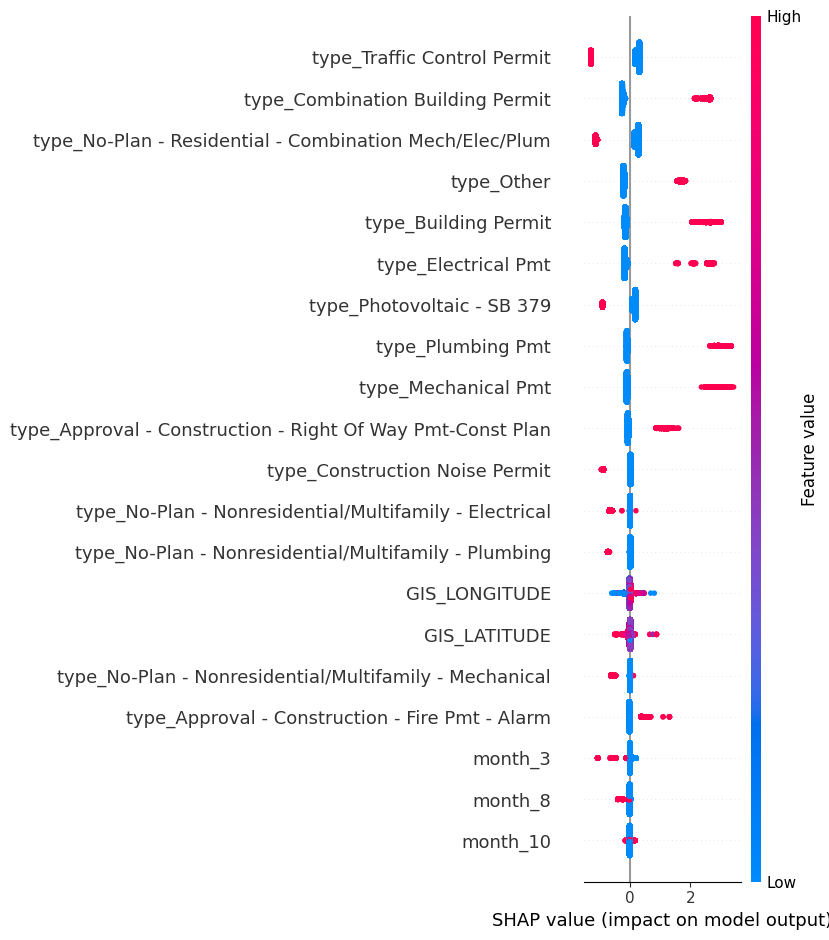

In [110]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)